# **Experiment Notebook**



In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

<hr>

## A. Project


Project name = Streaming Churn

Type = Classification

Experiment = 3

<hr>

## B. Experiment Description


experiment_hypothesis: Gradient Boosting and/or Balanced Random Forest will outperform the previous models in churn prediction, particularly in improving recall without sacrificing precision.

experiment_expectations: I expect to quickly see if Gradient Boosting and/or Balanced Random Forest can provide a better balance between precision and recall, resulting in improved F1-score and AUC-ROC, while also reducing the number of missed churners (false negatives).

<hr>

## C. Data Understanding


### C.0 Import Packages

In [ ]:
# Pandas for data handling
import pandas as pd

# Scikit Learn for ML training
import sklearn

# Numpy for numerical computing and array operations
import numpy as np

# Imbalanced-learn to ensemble methods for imbalanced datasets
import imblearn.ensemble

# Matplotlib for plotting
import matplotlib.pyplot as plt

# Seaborn for data visualization
import seaborn as sns

<hr>

### C.1   Load Datasets

In [ ]:
# Load training set
# Do not change this code

X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv')

In [ ]:
# Load validation set
# Do not change this code

X_val = pd.read_csv('X_val.csv')
y_val = pd.read_csv('y_val.csv')

In [ ]:
# Load testing set
# Do not change this code

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')

<hr>

<hr>

## D. Feature Selection


feature_selection_executive_summary: For this experiment, I maintain the same feature set as in Experiment 1 and 2: MonthlyCharges, TotalCharges, ViewingHoursPerWeek, AverageViewingDuration, and AccountAge. This decision allows for a direct comparison with previous models and leverages the established predictive power of these features, while focusing on the impact of the two algorithms themselves in improving churn prediction performance.

In [ ]:
#fill the feature list

features_list = ['MonthlyCharges', 'TotalCharges', 'ViewingHoursPerWeek', 'AverageViewingDuration', 'AccountAge']


> Results: The feature list contains the five original features.

<hr>

## E. Data Preparation

data_preparation_executive_summary: The data preparation process for this experiment was limited to the creation of feature datasets (X) containing only the five selected features: MonthlyCharges, TotalCharges, ViewingHoursPerWeek, AverageViewingDuration, and AccountAge.

In [ ]:
## Create new X dataset with selected features.

X_train = X_train[features_list]
X_val = X_val[features_list]
X_test = X_test[features_list]

<hr>

## F. Feature Engineering

data_preparation_executive_summary_2: For this experiment, I have decided against creating new features. I want to see the effect of the two models compared to the previous ones without the noise of a new feature.

<hr>

## G. Train Machine Learning Model

train_model_executive_summary: In this experiment, we implemented two models: Balanced Random Forest and Gradient Boosting Classifier. Both models were trained using the same feature set as previous experiments, with minimal hyperparameter tuning to establish baseline performances. The models were evaluated using standard metrics including accuracy, precision, recall, F1-score, and AUC-ROC for direct comparison with earlier experiments.

### G.1 Import Algorithm

> Rationale: Balanced Random Forest was selected for its built-in handling of class imbalance, addressing a key challenge in our churn prediction task. Gradient Boosting was chosen for its potential to capture complex patterns in the data while maintaining high accuracy, offering a different approach to the boosting methods used earlier.

In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier

from sklearn.ensemble import GradientBoostingClassifier

<hr>

### G.2 Set Hyperparameters

> Rationale: For both models, I used 100 estimators as a standard starting point, balancing model complexity with training time. The Gradient Boosting model included a validation fraction and early stopping criterion to prevent overfitting, while keeping the implementation straightforward for this comparative experiment.

In [ ]:
brf_model = BalancedRandomForestClassifier(n_estimators=100, random_state=42)

gb_model = GradientBoostingClassifier(n_estimators=100, validation_fraction=0.2, n_iter_no_change=10, random_state=42)


<hr>

### G.3 Fit Model

In [ ]:
brf_model.fit(X_train, y_train)


/root/venv/lib/python3.10/site-packages/imblearn/utils/fixes.py:85: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


BalancedRandomForestClassifier(random_state=42)

In [ ]:
gb_model.fit(X_train, y_train)

/root/venv/lib/python3.10/site-packages/sklearn/ensemble/_gb.py:437: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GradientBoostingClassifier(n_iter_no_change=10, random_state=42,
                           validation_fraction=0.2)

In [ ]:
y_pred_brf = brf_model.predict(X_val)
y_pred_proba_brf = brf_model.predict_proba(X_val)[:, 1]

y_pred_gb = gb_model.predict(X_val)
y_pred_proba_gb = gb_model.predict_proba(X_val)[:, 1]

<hr>

### G.4 Model Technical Performance

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

accuracy = accuracy_score(y_val, y_pred_brf)
precision = precision_score(y_val, y_pred_brf)
recall = recall_score(y_val, y_pred_brf)
f1 = f1_score(y_val, y_pred_brf)
auc_roc = roc_auc_score(y_val, y_pred_proba_brf)

print("\nBalanced Random Forest Results:")

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_brf))



Balanced Random Forest Results:
Accuracy: 0.6183
Precision: 0.2611
Recall: 0.6430
F1 Score: 0.3714
AUC-ROC: 0.6825

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.61      0.73      5704
           1       0.26      0.64      0.37      1213

    accuracy                           0.62      6917
   macro avg       0.58      0.63      0.55      6917
weighted avg       0.78      0.62      0.66      6917



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

accuracy = accuracy_score(y_val, y_pred_gb)
precision = precision_score(y_val, y_pred_gb)
recall = recall_score(y_val, y_pred_gb)
f1 = f1_score(y_val, y_pred_gb)
auc_roc = roc_auc_score(y_val, y_pred_proba_gb)

print("\nGradient Boosting Results:")

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_gb))



Gradient Boosting Results:
Accuracy: 0.8269
Precision: 0.5769
Recall: 0.0495
F1 Score: 0.0911
AUC-ROC: 0.7105

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90      5704
           1       0.58      0.05      0.09      1213

    accuracy                           0.83      6917
   macro avg       0.70      0.52      0.50      6917
weighted avg       0.79      0.83      0.76      6917



> Results: Balanced Random Forest significantly improved recall to 64.30%, but at the cost of reduced precision (26.11%) and overall accuracy (61.83%). This model identifies many more potential churners but with a high false positive rate. In contrast, Gradient Boosting maintained high accuracy (82.69%) and improved precision (57.69%) compared to previous models, but its recall remained low (4.95%).

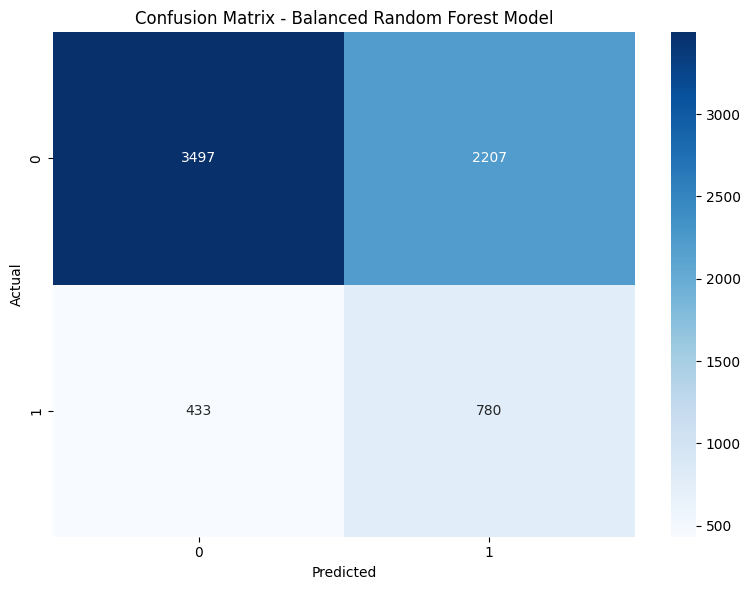

In [ ]:
from sklearn.metrics import confusion_matrix

# Plot confusion matrix
cm = confusion_matrix(y_val, y_pred_brf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Balanced Random Forest Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

<hr>

### G.5 Business Impact from Current Model Performance

In [ ]:
from sklearn.metrics import confusion_matrix

def churn_cost_calculation(y_true, y_pred):
    """
    Calculate the cost and benefit of the churn prevention strategy compared to taking no action.

    Parameters:
    y_true (array): True labels (1 for churn, 0 for non-churn)
    y_pred (array): Predicted labels (1 for churn, 0 for non-churn)

    Returns:
    dict: A dictionary containing cost calculations and key metrics
    """
    # Calculate confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Constants
    monthly_charge = 12.5  # average monthly charge
    discount_percentage = 0.5  # 50% discount
    discount_duration = 3  # 3 months

    # Scenario 1: Do nothing
    do_nothing_revenue = (tn + fp) * monthly_charge * discount_duration

    # Scenario 2: Apply discount to predicted churners
    discount_revenue = (tn * monthly_charge * discount_duration) + ((tp + fp) * monthly_charge * discount_percentage * discount_duration)

    # Benefit of the strategy
    benefit = discount_revenue - do_nothing_revenue

    return {
        "do_nothing_revenue": round(do_nothing_revenue, 2),
        "discount_revenue": round(discount_revenue, 2),
        "benefit": round(benefit, 2),
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn
    }

# Usage
results = churn_cost_calculation(y_val, y_pred_brf)

print(f"Revenue if do nothing: ${results['do_nothing_revenue']:,.2f}")
print(f"Revenue with discount strategy: ${results['discount_revenue']:,.2f}")
print(f"Benefit of discount strategy: ${results['benefit']:,.2f}")
print(f"True Positives (correctly predicted churners): {results['true_positives']}")
print(f"False Positives (incorrectly predicted churners): {results['false_positives']}")
print(f"False Negatives (missed churners): {results['false_negatives']}")
print(f"True Negatives (correctly predicted non-churners): {results['true_negatives']}")

Revenue if do nothing: $213,900.00
Revenue with discount strategy: $187,143.75
Benefit of discount strategy: $-26,756.25
True Positives (correctly predicted churners): 780
False Positives (incorrectly predicted churners): 2207
False Negatives (missed churners): 433
True Negatives (correctly predicted non-churners): 3497


> Results: The results reveal that the current churn prediction model and discount strategy may not be financially beneficial compared to taking no action. If no intervention were made, the company would earn 213,900 over the next three months. However, applying the discount strategy based on the model's predictions results in a revenue of 187,143.75, leading to a net loss of 26,756.25. While the model correctly identifies 780 potential churners (true positives), it also incorrectly flags 2,207 customers as likely to churn (false positives), resulting in many unnecessary discounts. The high number of false positives significantly impacts the strategy's profitability. Despite the model's ability to identify a large portion of potential churners, the financial cost of the false positives outweighs the benefits of retained customers. This suggests that the model needs further refinement to reduce false positives.

<hr>

## H. Experiment Outcomes

final_experiment_outcome = 'Hypothesis Rejected'

> Key Learnings: The Balanced Random Forest model reveals that significantly improving churn recall is achievable, but comes with substantial trade-offs. While successfully reducing missed churners and exceeding the 50% recall target, the model's high false positive rate leads to considerable costs in unnecessary discounts, potentially making it economically unviable.

> Recommendations for Next Experiment: For the next experiment, I want to focus on refining the Balanced Random Forest model through two key strategies: feature engineering and hyperparameter tuning. By creating a new, potentially interaction-based feature and optimizing model parameters like the number of estimators, max depth, and minimum samples per leaf, we aim to improve the model's precision while maintaining its high recall. This approach builds on the model's strength in identifying potential churners while addressing the issue of high false positives, striving for a more balanced and economically viable churn prediction model.

<hr>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=0e20096b-eda0-43a0-b83c-e24d084104d6' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>